In [196]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [198]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [200]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,False,False,True,False,False,False,False,True,False
414,False,False,False,False,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False,False,False,True,False
416,False,False,False,False,False,True,False,False,False,False,True,False


# Visualization

<Axes: >

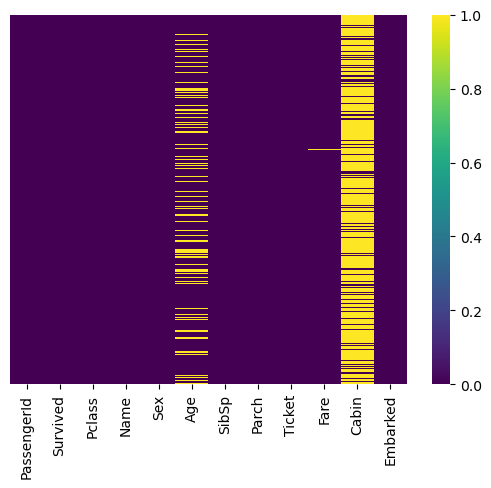

In [184]:
# Heat map of null values as per columns after cleaning 
sns.heatmap(df.isnull(), yticklabels = False, cmap = 'viridis')

<Axes: xlabel='Survived', ylabel='count'>

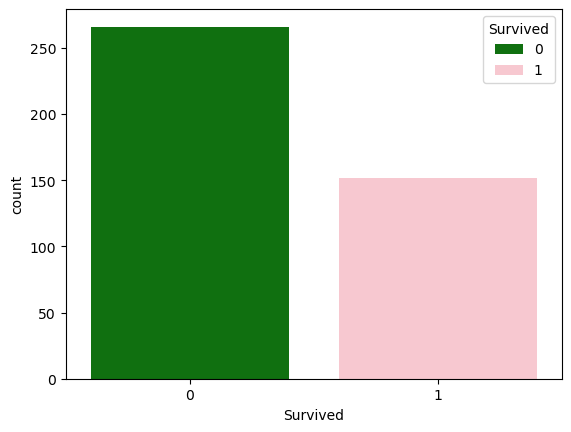

In [22]:
# A count plot displays the frequency of each unique category in a variable
sns.countplot( x = 'Survived', hue = 'Survived', data = df, palette = ['green', 'pink']) # hue = Within each category on the x-axis, split the data by another variable and color them differently

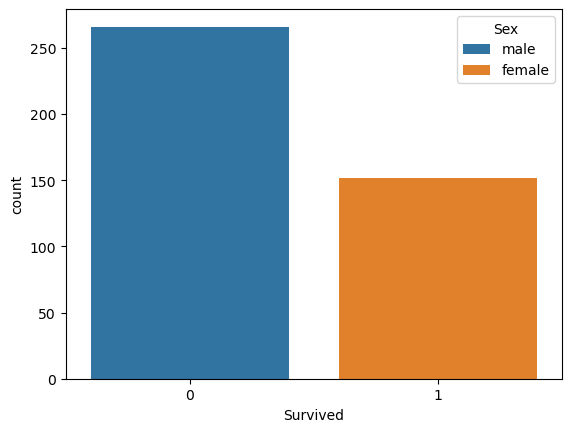

In [30]:
# To show how many people died from each gender 
sns.countplot( x = 'Survived', hue = 'Sex', data = df) 
plt.show()

In [32]:
df.groupby(['Survived', 'Sex']).size()  # This shows that there are no males who survived and no females who died (not practical)

Survived  Sex   
0         male      266
1         female    152
dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

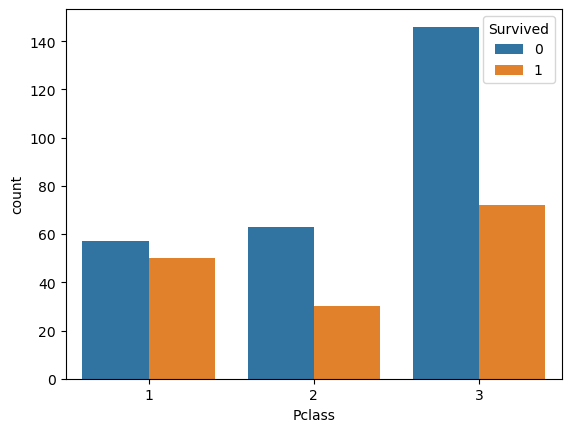

In [36]:
# number of people survived or died from each Pclass 
sns.countplot( x = 'Pclass', data = df, hue = 'Survived')   

<Axes: xlabel='Survived', ylabel='count'>

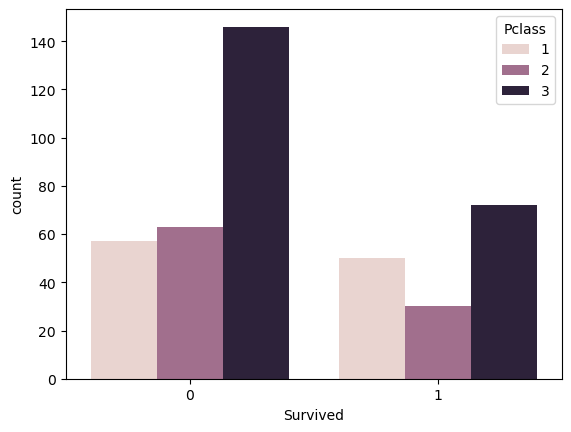

In [38]:
# NUmber of people died or survived in each Pclass
sns.countplot( x = 'Survived', data = df, hue = 'Pclass')

<Axes: xlabel='Age', ylabel='Count'>

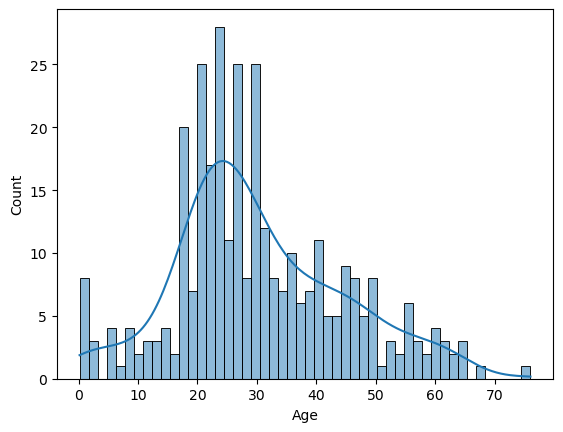

In [13]:
# Histogram showing range of ages of passengers 
sns.histplot(df['Age'].dropna(), bins = 50, kde = True)

<Axes: xlabel='Pclass', ylabel='Age'>

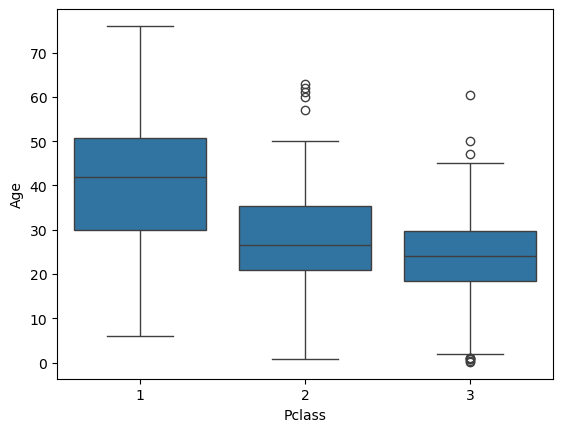

In [186]:
# plottig a boxplot of age and pclass to identify the median in each pclass
sns.boxplot( x = 'Pclass', y = 'Age', data = df)

In [202]:
# Filling the missing values in age
def fill_age(cols):      # cols = [22, 3]
    Age = cols[0]        # → 22
    Pclass = cols[1]     # → 3
    if pd.isnull(Age):
        if Pclass == 1:
            return 42      # Fills the missing value with the median age of each Pclass
        if Pclass == 2:
            return 27
        if Pclass == 3:
            return 24
    else:
        return Age       # if not null, returns the original age 

In [204]:
# choosing 2 cols of df and passing them as parameters in the function as a mini list
df['Age'] = df[['Age','Pclass']].apply(fill_age, axis = 1)    
df

C:\Users\kanis\AppData\Local\Temp\ipykernel_15496\2465197676.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]        # → 22
C:\Users\kanis\AppData\Local\Temp\ipykernel_15496\2465197676.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]     # → 3


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


In [206]:
# Creating bins as per age group 
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior Citizen']
df['Age_Group'] = pd.cut( df['Age'], bins = bins, labels = labels)   # Creating a new column for labelling
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Young Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Senior Citizen
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Young Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S,Young Adult
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Adult
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Adult
416,1308,0,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S,Young Adult


<Axes: xlabel='Age_Group', ylabel='Age'>

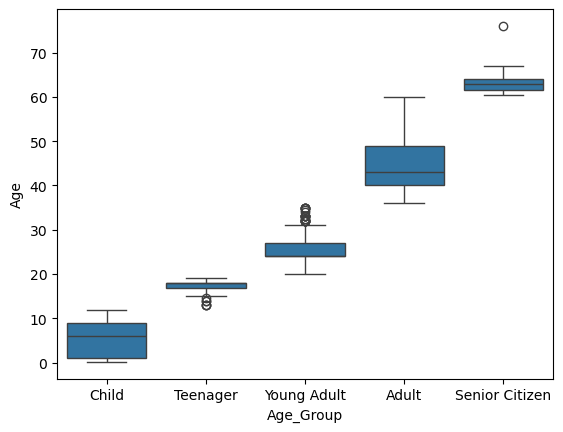

In [208]:
sns.boxplot( x = 'Age_Group', y = 'Age' , data = df)  # Shows the quartiles in each age group

In [210]:
df.drop('Ticket', axis = 1, inplace = True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_Group
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,NaN,Q,Young Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,NaN,S,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,NaN,Q,Senior Citizen
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,NaN,S,Young Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,NaN,S,Young Adult
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,24.0,0,0,8.0500,NaN,S,Young Adult
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,108.9000,C105,C,Adult
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,7.2500,NaN,S,Adult
416,1308,0,3,"Ware, Mr. Frederick",male,24.0,0,0,8.0500,NaN,S,Young Adult


In [212]:
# Creating dummy variables for categories, since ml models work better with numbers 
pd.get_dummies(df['Embarked'], drop_first = True).astype(int)   # Dropping the first column, as it can be represented by the other two

,Q,S
0,1,0
1,0,1
2,1,0
3,0,1
4,0,1
...,...,...
413,0,1
414,0,0
415,0,1
416,0,1


In [214]:
pd.get_dummies(df['Sex'],drop_first = True).astype(int)

,male
0,1
1,0
2,1
3,1
4,0
...,...
413,1
414,0
415,1
416,1


In [216]:
# Storing the dummy variiables into new variables 
Sex = pd.get_dummies(df['Sex'], drop_first = True).astype(int)
Embarked = pd.get_dummies(df['Embarked'], drop_first = True).astype(int)

In [218]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Age_Group
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,NaN,Q,Young Adult
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,NaN,S,Adult
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,NaN,Q,Senior Citizen
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,NaN,S,Young Adult
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,NaN,S,Young Adult


In [220]:
# Droppping unwanted columns 
df.drop(['Name','Sex','Embarked'], inplace = True, axis = 1)
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Age_Group
0,892,0,3,34.5,0,0,7.8292,NaN,Young Adult
1,893,1,3,47.0,1,0,7.0000,NaN,Adult
2,894,0,2,62.0,0,0,9.6875,NaN,Senior Citizen
3,895,0,3,27.0,0,0,8.6625,NaN,Young Adult
4,896,1,3,22.0,1,1,12.2875,NaN,Young Adult
...,...,...,...,...,...,...,...,...,...
413,1305,0,3,24.0,0,0,8.0500,NaN,Young Adult
414,1306,1,1,39.0,0,0,108.9000,C105,Adult
415,1307,0,3,38.5,0,0,7.2500,NaN,Adult
416,1308,0,3,24.0,0,0,8.0500,NaN,Young Adult


In [222]:
# Concatinating the newly created sex and embarked variables
df = pd.concat([df,Embarked,Sex], axis = 1)
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Age_Group,Q,S,male
0,892,0,3,34.5,0,0,7.8292,NaN,Young Adult,1,0,1
1,893,1,3,47.0,1,0,7.0000,NaN,Adult,0,1,0
2,894,0,2,62.0,0,0,9.6875,NaN,Senior Citizen,1,0,1
3,895,0,3,27.0,0,0,8.6625,NaN,Young Adult,0,1,1
4,896,1,3,22.0,1,1,12.2875,NaN,Young Adult,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,24.0,0,0,8.0500,NaN,Young Adult,0,1,1
414,1306,1,1,39.0,0,0,108.9000,C105,Adult,0,0,0
415,1307,0,3,38.5,0,0,7.2500,NaN,Adult,0,1,1
416,1308,0,3,24.0,0,0,8.0500,NaN,Young Adult,0,1,1


In [173]:
df  # After removing the tickect and cabin column

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Age_Group,Q,S,male
0,892,0,3,34.5,0,0,7.8292,Young Adult,1,0,1
1,893,1,3,47.0,1,0,7.0000,Adult,0,1,0
2,894,0,2,62.0,0,0,9.6875,Senior Citizen,1,0,1
3,895,0,3,27.0,0,0,8.6625,Young Adult,0,1,1
4,896,1,3,22.0,1,1,12.2875,Young Adult,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,24.0,0,0,8.0500,NaN,0,1,1
414,1306,1,1,39.0,0,0,108.9000,Adult,0,0,0
415,1307,0,3,38.5,0,0,7.2500,Adult,0,1,1
416,1308,0,3,24.0,0,0,8.0500,NaN,0,1,1
